# Combining AI and Indigenous Knowledge for Climate Action: A Bird Bioacoustic Monitoring Pipeline — The Lkotkote Case Study
Author(s):
*   Douglas Mbura, Co-founder, Lkotkote, Nairobi, Kenya

This tutorial builds a runnable, end-to-end version of the [Lkotkote](https://lkotkote.com/) bioacoustic monitoring pipeline, which combines AI-based bird sound identification with Samburu Traditional Ecological Knowledge (TEK) for climate-relevant biodiversity monitoring in northern Kenya. By the end, users will be able to take TEK-informed field sites and audio recordings through automated detection, AI species identification, community TEK enrichment, and open Darwin Core/GBIF publishing — and will understand where each real-world tool (AudioMoth, Raven Lite, Arbimon, BirdNET-Analyzer, the Lkotkote platform) plugs into that pipeline.


In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Table of Contents

*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Acronyms & Glossary](#acronyms-glossary)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
*   [Results & Discussion](#results-and-discussion)
*   [Pathway to Deployment & Pathway to Impact](#pathway-to-deployment)
*   [Quiz](#quiz)
*   [References](#references)


<a name="overview"></a>
# Overview

This tutorial introduces a **community-centered bird bioacoustic monitoring pipeline** that combines AI species detection at scale with Indigenous Traditional Ecological Knowledge (TEK) for meaning and interpretation. It is based on the real-world program run by **[Lkotkote](https://lkotkote.com/)**, an Indigenous-led environmental technology initiative working with the Samburu community in northern Kenya, whose name comes from the Samburu word for the Eastern Yellow-billed Hornbill.

**Learning outcomes.** By working through this notebook, users will be able to:
1. Explain why combining AI detection with TEK produces richer ecological intelligence than either alone.
2. Build a TEK-informed sensor deployment plan (site selection, GPS mapping, recording schedule).
3. Simulate and inspect passive acoustic monitoring data (waveforms, spectrograms) the way a reviewer would in Raven Lite.
4. Implement automated template-matching detection (in the style of Arbimon's Pattern Matching) and a simplified AI species classifier (standing in for BirdNET-Analyzer).
5. Enrich AI detections with structured TEK annotations and export the result as Darwin Core–compliant, GBIF-ready biodiversity data.
6. Identify the responsible-AI and Indigenous data sovereignty considerations (the CARE Principles) that govern this kind of work.

Because this is a workshop notebook, it does not require an AudioMoth, a Raven Lite license, an Arbimon account, or access to Lkotkote platform — every stage generates realistic bird-call audio so the pipeline runs end-to-end, reproducibly, on any laptop. Wherever a real tool or platform would be used in the field, a callout box says so explicitly.

The diagram below summarizes the six-stage pipeline this notebook builds, stage by stage.


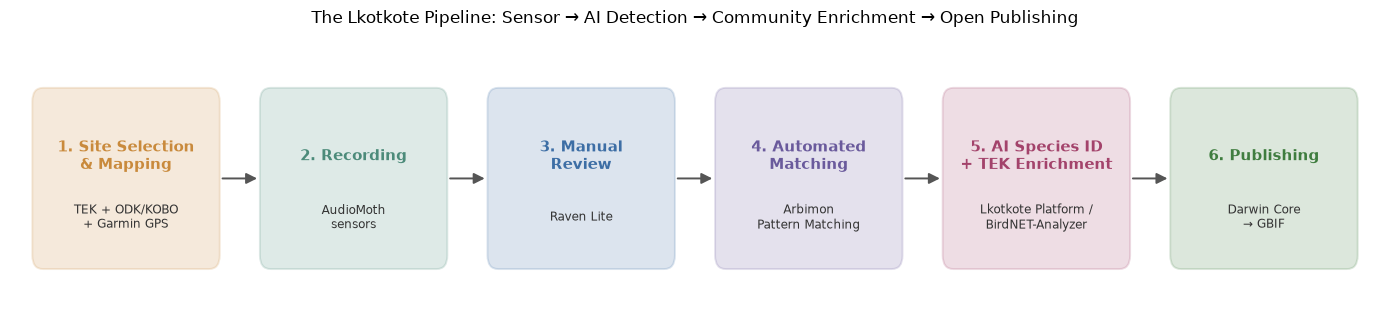

In [2]:
#@title Figure: The Lkotkote Pipeline { display-mode: "form" }

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [
    ("1. Site Selection\n& Mapping", "TEK + ODK/KOBO\n+ Garmin GPS", "#c98a3c"),
    ("2. Recording", "AudioMoth\nsensors", "#4c8b7a"),
    ("3. Manual\nReview", "Raven Lite", "#3d6ea5"),
    ("4. Automated\nMatching", "Arbimon\nPattern Matching", "#6a5a9c"),
    ("5. AI Species ID\n+ TEK Enrichment", "Lkotkote Platform /\nBirdNET-Analyzer", "#a3436b"),
    ("6. Publishing", "Darwin Core\n\u2192 GBIF", "#3f7d3f"),
]

fig, ax = plt.subplots(figsize=(14, 3.4))
box_w, box_h, gap = 2.0, 1.5, 0.55
x = 0.3
for title, subtitle, color in stages:
    box = FancyBboxPatch((x, 0.5), box_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.12",
                          linewidth=1.4, edgecolor=color, facecolor=color, alpha=0.18)
    ax.add_patch(box)
    ax.text(x + box_w / 2, 0.5 + box_h * 0.63, title, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color=color)
    ax.text(x + box_w / 2, 0.5 + box_h * 0.27, subtitle, ha="center", va="center",
            fontsize=8.5, color="#333333")
    if x + box_w + gap < 0.3 + len(stages) * (box_w + gap):
        arrow = FancyArrowPatch((x + box_w + 0.05, 0.5 + box_h / 2), (x + box_w + gap - 0.05, 0.5 + box_h / 2),
                                 arrowstyle="-|>", mutation_scale=16, color="#555555", linewidth=1.4)
        ax.add_patch(arrow)
    x += box_w + gap

ax.set_xlim(0, x - gap + 0.3)
ax.set_ylim(0, 2.5)
ax.axis("off")
ax.set_title("The Lkotkote Pipeline: Sensor \u2192 AI Detection \u2192 Community Enrichment \u2192 Open Publishing",
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this figure:** each box is one stage of the pipeline, in the order data flows through it — left to right, sensor to publication. The subtitle in each box names the real-world tool used at that stage (e.g. AudioMoth for recording, Arbimon for automated matching). Everywhere this notebook builds a *simulated* version of a stage, the corresponding real tool is named explicitly in the surrounding text, so you always know what a production deployment would swap in.

<a name="climate-impact"></a>
# Climate Impact

### Birds as seasonal and climate indicators

In semi-arid landscapes like Samburu, northern Kenya, rainfall is short, seasonal, and unevenly distributed — and it drives almost everything, from vegetation flush to insect emergence to breeding cycles. Birds are among the most climate-sensitive organisms on Earth: their calling behaviour, breeding timing, and habitat use shift in response to rainfall and temperature, often **before** those changes are visible to satellite or ground-station instruments. A rise in the calling activity of certain species, or the arrival of others, is frequently a leading indicator of imminent rain — sometimes days ahead of meteorological confirmation. Recording and identifying bird sound over time therefore gives us a living, continuous signal of ecological and climatic change.

### Why Traditional Ecological Knowledge matters here

AI models such as BirdNET-Analyzer are excellent at answering *"what species is this, and when did it call?"* at a scale no human team could match. But they cannot tell us what a call *means* locally — that a particular species' vocalization signals the onset of rains, or that a certain tree is favoured nesting habitat because of its shade and insect life. That interpretive layer comes from Traditional Ecological Knowledge, held by the community that has lived alongside these species for generations. Samburu community members hold detailed, long-term ecological observation — passed down and refined over generations — that in many cases predates and complements formal scientific monitoring. Combining the two, **AI detection at scale with TEK for meaning**, is what turns a folder of audio files into genuine ecological intelligence.

### Real-world impact: who uses this, and how

- **Who uses the outputs:** the Samburu community itself, conservation researchers, and organizations such as GBIF-connected biodiversity data users.
- **How the models are used:** BirdNET-style detections flag *when and where* target species were calling; TEK annotations then interpret what that activity means for the season (e.g., imminent rain, fruiting cycles) and for the ecosystem (nesting, water availability).
- **What decisions are informed:** community-level adaptive decisions such as livestock movement timing and water access planning, as well as conservation prioritization by researchers and NGOs working in the region.
- **Impact on communities on the ground:** done well (see the CARE Principles in Background & Prerequisites and the Limitations discussion later), this gives the community a durable, attributed record of its own ecological knowledge rather than an extractive dataset that only benefits outside researchers. Done poorly, it risks stripping TEK of attribution and control — which is why data governance is treated as a first-class part of this pipeline, not an afterthought.

This same architecture — **sensor → AI detection → community enrichment → open publishing** — generalizes to other climate-sensitive indicator species and other Indigenous or local-knowledge contexts well beyond birds and beyond Samburu.


<a name="background-and-prereqs"></a>
# Background & Prerequisites

### Prerequisites

- Basic Python (functions, dictionaries, `for` loops).
- Basic familiarity with `pandas` DataFrames.
- No signal-processing or bioacoustics background is required — every concept used is explained inline.

### Key concepts

| Concept | What it means here |
|---|---|
| **Bioacoustic monitoring** | Using audio sensors to detect and identify species by sound over long, unattended deployments. |
| **AudioMoth** | A low-cost, purpose-built acoustic logger used for long-term, standardized ecological monitoring in the field. |
| **Raven Lite** | Free software from the Cornell Lab of Ornithology for viewing waveforms/spectrograms and manually annotating candidate calls. |
| **Arbimon** | A platform that scans large audio archives for a target call using a template built from a verified example. |
| **BirdNET-Analyzer** | An open-source deep learning model (Cornell Lab / Chemnitz University of Technology) that identifies bird species from audio at scale, with confidence scores and timestamps. |
| **Traditional Ecological Knowledge (TEK)** | Long-term, community-held ecological observation — in this case, Samburu knowledge of which species and calls signal seasonal and climatic change. |
| **Darwin Core / GBIF** | An open, standardized data schema (Darwin Core) for publishing biodiversity records to the Global Biodiversity Information Facility (GBIF). |
| **CARE Principles** | A framework (Collective Benefit, Authority to Control, Responsibility, Ethics) for governing Indigenous data, used alongside the FAIR principles common in open science. |

### Pipeline overview

| Stage | Tool (real-world) | What we'll do in this notebook |
|---|---|---|
| 1. Site selection & mapping | Community TEK + ODK/KOBO + Garmin GPS | Build a TEK-informed site table |
| 2. Recording | AudioMoth sensors | Simulate multi-site audio deployment |
| 3. Manual review | Raven Lite | Visualize waveform + spectrogram, select calls |
| 4. Automated matching | Arbimon (Pattern Matching) | Template-based cross-correlation matching |
| 5. AI species ID & TEK enrichment | Lkotkote Platform / BirdNET-Analyzer | Simplified classifier + TEK annotation layer |
| 6. Publishing | Darwin Core → GBIF | Export Occurrence / Event / MeasurementOrFact tables |


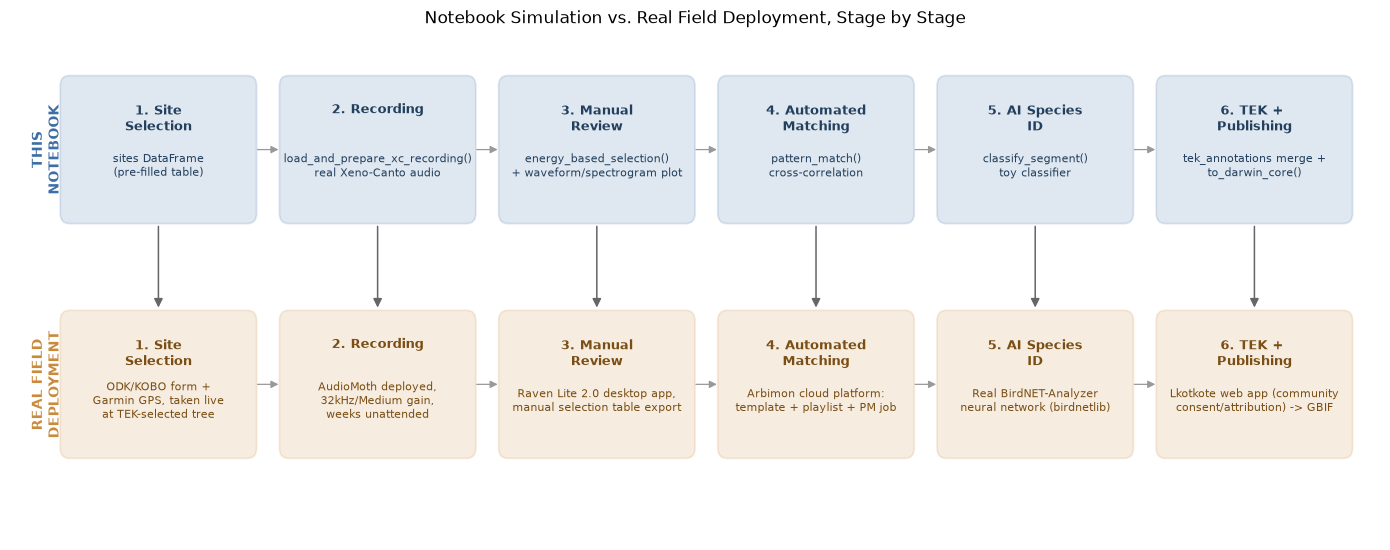

In [3]:
#@title Figure: Notebook Simulation vs. Real Field Deployment { display-mode: "form" }

# Block diagram: what changes between THIS NOTEBOOK and a REAL FIELD DEPLOYMENT,
# stage by stage. This directly illustrates callouts like the "In the field..."
# note later in Data Description.
fig, ax = plt.subplots(figsize=(14, 5.6))

stage_pairs = [
    ("1. Site\nSelection", "sites DataFrame\n(pre-filled table)", "ODK/KOBO form +\nGarmin GPS, taken live\nat TEK-selected tree"),
    ("2. Recording", "load_and_prepare_xc_recording()\nreal Xeno-Canto audio", "AudioMoth deployed,\n32kHz/Medium gain,\nweeks unattended"),
    ("3. Manual\nReview", "energy_based_selection()\n+ waveform/spectrogram plot", "Raven Lite 2.0 desktop app,\nmanual selection table export"),
    ("4. Automated\nMatching", "pattern_match()\ncross-correlation", "Arbimon cloud platform:\ntemplate + playlist + PM job"),
    ("5. AI Species\nID", "classify_segment()\ntoy classifier", "Real BirdNET-Analyzer\nneural network (birdnetlib)"),
    ("6. TEK + \nPublishing", "tek_annotations merge +\nto_darwin_core()", "Lkotkote web app (community\nconsent/attribution) -> GBIF"),
]

n = len(stage_pairs)
col_w, gap = 2.05, 0.35
notebook_y, field_y = 3.15, 0.85
box_h = 1.35

for idx, (title, nb_text, field_text) in enumerate(stage_pairs):
    x = 0.25 + idx * (col_w + gap)
    ax.add_patch(FancyBboxPatch((x, notebook_y), col_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.1",
                                 linewidth=1.3, edgecolor="#3d6ea5", facecolor="#3d6ea5", alpha=0.16))
    ax.text(x + col_w / 2, notebook_y + box_h - 0.22, title, ha="center", va="top",
            fontsize=9.5, fontweight="bold", color="#22405e")
    ax.text(x + col_w / 2, notebook_y + box_h * 0.38, nb_text, ha="center", va="center",
            fontsize=7.8, color="#22405e")

    ax.add_patch(FancyBboxPatch((x, field_y), col_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.1",
                                 linewidth=1.3, edgecolor="#c98a3c", facecolor="#c98a3c", alpha=0.16))
    ax.text(x + col_w / 2, field_y + box_h - 0.22, title, ha="center", va="top",
            fontsize=9.5, fontweight="bold", color="#7a4e14")
    ax.text(x + col_w / 2, field_y + box_h * 0.38, field_text, ha="center", va="center",
            fontsize=7.8, color="#7a4e14")

    arrow = FancyArrowPatch((x + col_w / 2, notebook_y - 0.05), (x + col_w / 2, field_y + box_h + 0.05),
                             arrowstyle="-|>", mutation_scale=13, color="#666666", linewidth=1.1,
                             connectionstyle="arc3,rad=0")
    ax.add_patch(arrow)

    if idx < n - 1:
        nxt_x = 0.25 + (idx + 1) * (col_w + gap)
        for y0 in (notebook_y + box_h / 2, field_y + box_h / 2):
            ax.add_patch(FancyArrowPatch((x + col_w + 0.03, y0), (nxt_x - 0.03, y0),
                                          arrowstyle="-|>", mutation_scale=11, color="#999999", linewidth=0.9))

ax.text(0.05, notebook_y + box_h / 2, "THIS\nNOTEBOOK", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#3d6ea5", rotation=90)
ax.text(0.05, field_y + box_h / 2, "REAL FIELD\nDEPLOYMENT", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#c98a3c", rotation=90)

ax.set_xlim(-0.35, 0.25 + n * (col_w + gap))
ax.set_ylim(0, notebook_y + box_h + 0.4)
ax.axis("off")
ax.set_title("Notebook Simulation vs. Real Field Deployment, Stage by Stage", fontsize=12.5, pad=12)
plt.tight_layout()
plt.show()
plt.close(fig)


**Reading this figure:** each column is one pipeline stage; the blue box shows what this notebook actually runs, the orange box shows its real-world counterpart, and the vertical arrow is the substitution you'd make to go from workshop notebook to field deployment. Nothing about the *pipeline logic* changes top-to-bottom — only the concrete tool or data source at each stage. This is the same six stages introduced in the diagram in Overview, now split to show notebook vs. field side by side.

## Videos
The talk below, from BirdNET creator Stefan Kahl, gives useful background on how BirdNET-style acoustic classifiers are built and adapted — directly relevant to the simplified classifier used in the Methodology section.


📺 **Watch:** [BioacousTalks — Custom Machine Learning Models with BirdNET Analyzer GUI (Stefan Kahl)](https://www.youtube.com/watch?v=HuEZGIPeyq0)

## Other References
- Lkotkote: [https://lkotkote.com](https://lkotkote.com)
- Open Acoustic Devices (AudioMoth): [https://www.openacousticdevices.info](https://www.openacousticdevices.info)
- Raven Lite 2.0: [https://store.birds.cornell.edu/collections/downloadable-software/products/raven-lite-2-0-free-license](https://store.birds.cornell.edu/collections/downloadable-software/products/raven-lite-2-0-free-license)
- Arbimon: [https://arbimon.org/](https://arbimon.org/)
- BirdNET-Analyzer: [https://github.com/birdnet-team/BirdNET-Analyzer](https://github.com/birdnet-team/BirdNET-Analyzer)
- GBIF: [https://www.gbif.org](https://www.gbif.org)
- Darwin Core standard: [https://dwc.tdwg.org](https://dwc.tdwg.org)
- CARE Principles for Indigenous Data Governance: [https://www.gida-global.org/care](https://www.gida-global.org/careprinciples)

<a name="acronyms-glossary"></a>
### Acronyms


| Acronym | Meaning |
|---|---|
| **AI** | Artificial Intelligence |
| **TEK** | Traditional Ecological Knowledge |
| **CARE** | Collective Benefit, Authority to Control, Responsibility, Ethics — Indigenous data governance principles |
| **FAIR** | Findable, Accessible, Interoperable, Reusable — principles common in open science |
| **GBIF** | Global Biodiversity Information Facility |
| **DwC** | Darwin Core biodiversity data standard |
| **GPS** | Global Positioning System |
| **ODK / KOBO** | Open Data Kit / KoboToolbox — mobile field-data-collection software |
| **PM** | Pattern Matching (an Arbimon analysis mode) |
| **PCM** | Pulse-Code Modulation (WAV audio encoding) |
| **SD (card)** | Secure Digital memory card |
| **CNN** | Convolutional Neural Network |

### Glossary of Samburu terms used in this notebook

| Term | Meaning |
|---|---|
| Lkotkote | Samburu word for the Eastern Yellow-billed Hornbill; name of the platform and project |
| Arany | Local name used in call/template naming, tied to the birds' song |
| Mairii | Local name for the Lesser Masked Weaver |
| Lkeresire | Local name for the Vulturine Guineafowl |
| Laawa, Lchura, Lesiteti, Lmurgusiani, Ltoroto Logiria, Nelmasuuti, Soito Naarok | Culturally and ecologically named field sites |


<a name="software-requirements"></a>
# Software Requirements

This notebook requires Python >= 3.9. The following libraries are required:

*   numpy
*   pandas
*   scipy
*   matplotlib
*   librosa (audio loading/resampling for the real Xeno-Canto recordings used below)
*   soundfile (WAV I/O backend for librosa)
*   codecarbon (for energy/emissions instrumentation in the Methodology section)
*   watermark (for dependency reporting at the end of this notebook)

A companion `requirements.txt` (generated with the actual installed versions in this environment) is submitted alongside this notebook and lists exact pinned versions. Avoid installing undocumented dependencies beyond what is listed there. `librosa`'s MP3 decoding also requires **ffmpeg** to be available on the system PATH — this is preinstalled on Google Colab; if running locally, install it via your OS package manager first.

**Analysis period:** this notebook was developed in June-July 2026 and last executed/verified on **2026-07-16**, ahead of the Climate Change AI Virtual Summer School (July 19 - August 22, 2026). If any referenced package or platform (e.g. BirdNET-Analyzer, Arbimon, Lkotkote) has changed materially since that date, treat version-specific details as illustrative rather than current.

**Audio data:** this notebook uses four real field recordings sourced from **[Xeno-Canto](https://xeno-canto.org/)**, a citizen-science archive of wildlife sound recordings, shipped alongside this notebook in the `xeno_canto_source/` folder. Xeno-Canto recordings are contributed under a variety of Creative Commons licenses set by each recordist; the exact licence and required attribution for each of the four recordings used here is listed in References. If you plan to redistribute this notebook or its outputs beyond this workshop, check each recording's individual Xeno-Canto license page first.


In [4]:
!pip install -q numpy pandas scipy matplotlib librosa soundfile codecarbon watermark


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# Data manipulation & numerics
import os
import uuid
import datetime as dt

import numpy as np
import pandas as pd
from scipy import signal
from scipy.io import wavfile
import librosa
import soundfile as sf
import IPython.display as ipd

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Reproducibility
RNG = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports complete.")

Imports complete.


In [6]:
# Directory structure (relative paths) for retrieving/writing all tutorial data.
# Real deployments would place actual AudioMoth .WAV files under DATA_DIR/raw_recordings/<site>/<date>/.
DATA_DIR = "./lkotkote_data"
RAW_DIR = os.path.join(DATA_DIR, "raw_recordings")
EXPORT_DIR = os.path.join(DATA_DIR, "darwin_core_export")

for directory in [DATA_DIR, RAW_DIR, EXPORT_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Working directories ready (relative paths):")
for directory in [DATA_DIR, RAW_DIR, EXPORT_DIR]:
    print(" -", os.path.relpath(directory))

Working directories ready (relative paths):
 - lkotkote_data
 - lkotkote_data/raw_recordings
 - lkotkote_data/darwin_core_export


<a name="data-description"></a>
# Data Description

This tutorial uses three linked pieces of data:

1. **TEK-informed site metadata** — a small tabular dataset (7 rows) with site name, dominant tree/habitat feature, target bird species, and GPS coordinates. In a real deployment this is captured with ODK/KOBO Toolkit and a handheld Garmin GPS.
2. **Real field recordings from Xeno-Canto** — four real bird-call recordings (MP3, downloaded from [xeno-canto.org](https://xeno-canto.org/) and shipped in `xeno_canto_source/`) for four species with documented Samburu TEK associations: Lesser Masked Weaver, White-bellied Go-away-bird, Pied (Jacobin) Cuckoo, and Verreaux's Eagle-Owl. Each is resampled to 32 kHz mono 16-bit PCM (matching the AudioMoth settings below) and written into the same `raw_recordings/<site_name>/<date>/*.WAV` folder layout a real deployment would produce. **These are genuine field recordings, not synthetic audio** — earlier drafts of this notebook used synthetic frequency-modulated chirps as a placeholder; this version replaces that placeholder with real recordings throughout.
3. **TEK annotation metadata** — local species names, seasonal/behavioural indicators, and cultural meaning for each species, sourced directly from Samburu community knowledge (see References for the source document), used later to enrich AI detections (the "Lkotkote layer").

Because the Xeno-Canto recordings are real, third-party, licensed content (not workshop-generated data), a lightweight **datasheet** is appropriate and provided in the table below, alongside the source citation for each recording (full citations in References). For a real Lkotkote TEK dataset, a datasheet documenting consent, provenance, and community authority to control (per the CARE Principles) would additionally be required before any external release.

### Datasheet — Xeno-Canto audio bundle used in this notebook

| Field | Detail |
|---|---|
| **Motivation** | Demonstrate the pipeline on real bioacoustic field recordings rather than synthetic audio |
| **Composition** | 4 MP3 recordings, one per species, 7-42 seconds each, sourced from Xeno-Canto |
| **Collection process** | Recorded and uploaded to Xeno-Canto by independent citizen-science contributors (not by Lkotkote); not GPS-matched to the Lkotkote/Samburu site table below |
| **Preprocessing applied here** | Resampled to 32 kHz mono, 16-bit PCM WAV, peak-normalized |
| **Recommended use** | Educational demonstration of the detection/classification pipeline on real audio |
| **Known constraint** | These recordings were **not** made at the Lkotkote Samburu sites — they are used here as realistic stand-ins for the *same species* referenced in the Samburu TEK record, since the actual Lkotkote field archive isn't publicly distributable |
| **License / attribution** | Per-recording Creative Commons license set by the original recordist; see References for citation details |

In [7]:
#@title Table: TEK-informed Sites { display-mode: "form" }

# TEK-informed site table, based on the Lkotkote field program.
# Coordinates are illustrative points within the Samburu landscape (northern Kenya).
sites = pd.DataFrame([
    {
        "site_name": "Laawa", "tree_species": "Delonix elata",
        "habitat_note": "Favourite perching/nesting tree",
        "target_species": "Superb Starling, White-browed Sparrow-Weaver, Northern Grey-headed Sparrow, "
                           "Speckled Mousebird, Little Bee-eater",
        "lat": 1.1421, "lon": 36.9560,
    },
    {
        "site_name": "Lchura", "tree_species": "Vachellia reficiens (Red-barked Acacia)",
        "habitat_note": "Shaded acacia offering shelter from sun",
        "target_species": "Lesser Masked Weaver (\"Mairii\"), Red-billed Hornbill, Von der Decken's Hornbill, "
                           "Mousebirds, Grey Go-away-bird, Fiscal Shrike",
        "lat": 1.1483, "lon": 36.9701,
    },
    {
        "site_name": "Lesiteti", "tree_species": "Grewia mollis (Siteti tree)",
        "habitat_note": "Fruiting tree, food source for birds & animals",
        "target_species": "African Paradise Flycatcher, Bulbuls, Starlings, Sunbirds",
        "lat": 1.1362, "lon": 36.9438,
    },
    {
        "site_name": "Lmurgusiani", "tree_species": "Gardenia jovis-tonantis",
        "habitat_note": "Fruit, flowers and insects attract birds",
        "target_species": "African Grey Hornbill, Bulbuls, Flycatchers",
        "lat": 1.1509, "lon": 36.9385,
    },
    {
        "site_name": "Ltoroto Logiria", "tree_species": "Lawsonia inermis (Logiria)",
        "habitat_note": "Typically found near streams and water points",
        "target_species": "Waterside foraging species (site-dependent)",
        "lat": 1.1275, "lon": 36.9622,
    },
    {
        "site_name": "Nelmasuuti", "tree_species": "Lmasuuti grass",
        "habitat_note": "Grassland habitat for ground-dwelling flocks",
        "target_species": "Vulturine Guineafowl (\"Lkeresire\")",
        "lat": 1.1198, "lon": 36.9503,
    },
    {
        "site_name": "Soito Naarok", "tree_species": "N/A — \"black rock\" (soito=rock, naarok=black)",
        "habitat_note": "Favoured raptor perch overlooking rocky ground",
        "target_species": "Raptors (hunting lizards, snakes, mice)",
        "lat": 1.1450, "lon": 36.9820,
    },
])
sites

,site_name,tree_species,habitat_note,target_species,lat,lon
0,Laawa,Delonix elata,Favourite perching/nesting tree,"Superb Starling, White-browed Sparrow-Weaver, ...",1.1421,36.9560
1,Lchura,Vachellia reficiens (Red-barked Acacia),Shaded acacia offering shelter from sun,"Lesser Masked Weaver (""Mairii""), Red-billed Ho...",1.1483,36.9701
2,Lesiteti,Grewia mollis (Siteti tree),"Fruiting tree, food source for birds & animals","African Paradise Flycatcher, Bulbuls, Starling...",1.1362,36.9438
3,Lmurgusiani,Gardenia jovis-tonantis,"Fruit, flowers and insects attract birds","African Grey Hornbill, Bulbuls, Flycatchers",1.1509,36.9385
4,Ltoroto Logiria,Lawsonia inermis (Logiria),Typically found near streams and water points,Waterside foraging species (site-dependent),1.1275,36.9622
5,Nelmasuuti,Lmasuuti grass,Grassland habitat for ground-dwelling flocks,"Vulturine Guineafowl (""Lkeresire"")",1.1198,36.9503
6,Soito Naarok,"N/A — ""black rock"" (soito=rock, naarok=black)",Favoured raptor perch overlooking rocky ground,"Raptors (hunting lizards, snakes, mice)",1.1450,36.9820


In [8]:
#@title Table: Audio Recordings { display-mode: "form" }

# Real audio recordings used in this notebook, sourced from Xeno-Canto (xeno-canto.org).
# Each is mapped to one TEK-informed site above, chosen for habitat/niche fit
# (these recordings were not made at the literal Lkotkote sites -- see the
# datasheet note above -- but represent the same species referenced in the
# Samburu TEK record).
XC_RECORDINGS = pd.DataFrame([
    {
        "species": "Lesser Masked Weaver (Mairii)",
        "scientific_name": "Ploceus intermedius",
        "samburu_name": "Mairii",
        "site_name": "Lchura",
        "xc_id": "XC449647",
        "mp3_path": "xeno_canto_source/xeno_canto_source/lesser_masked_weaver_XC449647.mp3",
    },
    {
        "species": "White-bellied Go-away-bird (Lkuak)",
        "scientific_name": "Crinifer leucogaster",
        "samburu_name": "Lkuak",
        "site_name": "Laawa",
        "xc_id": "XC747720",
        "mp3_path": "xeno_canto_source/xeno_canto_source/white_bellied_goawaybird_XC747720.mp3",
    },
    {
        "species": "Pied (Jacobin) Cuckoo (Chupaa)",
        "scientific_name": "Clamator jacobinus",
        "samburu_name": "Chupaa",
        "site_name": "Lesiteti",
        "xc_id": "XC601197",
        "mp3_path": "xeno_canto_source/xeno_canto_source/pied_jacobin_cuckoo_XC601197.mp3",
    },
    {
        "species": "Verreaux's Eagle-Owl (Lugut)",
        "scientific_name": "Bubo lacteus",
        "samburu_name": "Lugut",
        "site_name": "Soito Naarok",
        "xc_id": "XC811860",
        "mp3_path": "xeno_canto_source/xeno_canto_source/verreauxs_eagle_owl_XC811860.mp3",
    },
])
XC_RECORDINGS

,species,scientific_name,samburu_name,site_name,xc_id,mp3_path
0,Lesser Masked Weaver (Mairii),Ploceus intermedius,Mairii,Lchura,XC449647,xeno_canto_source/xeno_canto_source/lesser_mas...
1,White-bellied Go-away-bird (Lkuak),Crinifer leucogaster,Lkuak,Laawa,XC747720,xeno_canto_source/xeno_canto_source/white_bell...
2,Pied (Jacobin) Cuckoo (Chupaa),Clamator jacobinus,Chupaa,Lesiteti,XC601197,xeno_canto_source/xeno_canto_source/pied_jacob...
3,Verreaux's Eagle-Owl (Lugut),Bubo lacteus,Lugut,Soito Naarok,XC811860,xeno_canto_source/xeno_canto_source/verreauxs_...


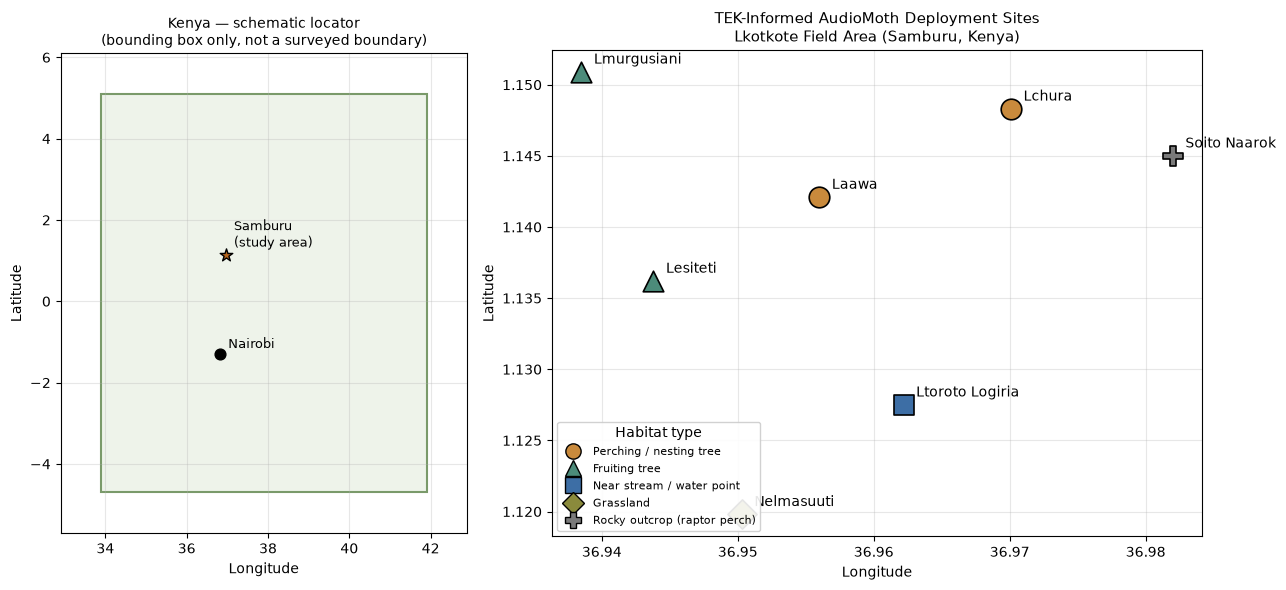

In [9]:
#@title Figure: Study Area { display-mode: "form" }

HABITAT_MARKER = {
    "Laawa": ("o", "#c98a3c"),
    "Lchura": ("o", "#c98a3c"),
    "Lesiteti": ("^", "#4c8b7a"),
    "Lmurgusiani": ("^", "#4c8b7a"),
    "Ltoroto Logiria": ("s", "#3d6ea5"),
    "Nelmasuuti": ("D", "#8a8a3c"),
    "Soito Naarok": ("P", "#7a7a7a"),
}

# Kenya's approximate bounding box, for a schematic (not surveyed) regional locator only.
KENYA_BBOX = {"lon_min": 33.9, "lon_max": 41.9, "lat_min": -4.7, "lat_max": 5.1}
NAIROBI = (36.817, -1.286)
SAMBURU_CENTER = (sites["lon"].mean(), sites["lat"].mean())

fig, (ax_locator, ax_detail) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 1.6]})

ax_locator.add_patch(mpatches.Rectangle(
    (KENYA_BBOX["lon_min"], KENYA_BBOX["lat_min"]),
    KENYA_BBOX["lon_max"] - KENYA_BBOX["lon_min"],
    KENYA_BBOX["lat_max"] - KENYA_BBOX["lat_min"],
    facecolor="#eef3ea", edgecolor="#7a9a6a", linewidth=1.5))
ax_locator.scatter(*NAIROBI, s=60, color="black", zorder=3)
ax_locator.annotate("Nairobi", NAIROBI, textcoords="offset points", xytext=(6, 4), fontsize=9)
ax_locator.scatter(*SAMBURU_CENTER, s=90, color="#b5651d", edgecolor="black", zorder=3, marker="*")
ax_locator.annotate("Samburu\n(study area)", SAMBURU_CENTER, textcoords="offset points", xytext=(6, 6), fontsize=9)
ax_locator.set_xlim(KENYA_BBOX["lon_min"] - 1, KENYA_BBOX["lon_max"] + 1)
ax_locator.set_ylim(KENYA_BBOX["lat_min"] - 1, KENYA_BBOX["lat_max"] + 1)
ax_locator.set_title("Kenya — schematic locator\n(bounding box only, not a surveyed boundary)", fontsize=10)
ax_locator.set_xlabel("Longitude")
ax_locator.set_ylabel("Latitude")
ax_locator.set_aspect("equal")

for _, row in sites.iterrows():
    marker, color = HABITAT_MARKER[row["site_name"]]
    ax_detail.scatter(row["lon"], row["lat"], s=220, marker=marker, color=color,
                       edgecolor="black", linewidth=1.2, zorder=3)
    ax_detail.annotate(row["site_name"], (row["lon"], row["lat"]),
                        textcoords="offset points", xytext=(9, 6), fontsize=10)
ax_detail.set_xlabel("Longitude")
ax_detail.set_ylabel("Latitude")
ax_detail.set_title("TEK-Informed AudioMoth Deployment Sites\nLkotkote Field Area (Samburu, Kenya)", fontsize=11)

legend_handles = [
    plt.Line2D([], [], marker=m, color="w", markerfacecolor=c, markeredgecolor="black",
               markersize=11, label=label)
    for label, (m, c) in {
        "Perching / nesting tree": HABITAT_MARKER["Laawa"],
        "Fruiting tree": HABITAT_MARKER["Lesiteti"],
        "Near stream / water point": HABITAT_MARKER["Ltoroto Logiria"],
        "Grassland": HABITAT_MARKER["Nelmasuuti"],
        "Rocky outcrop (raptor perch)": HABITAT_MARKER["Soito Naarok"],
    }.items()
]
ax_detail.legend(handles=legend_handles, loc="lower left", fontsize=8, title="Habitat type", framealpha=0.9)

plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this figure:** the left panel is a schematic locator showing roughly where the Samburu study area sits within Kenya (bounding box only — not a surveyed boundary). The right panel zooms into the seven TEK-selected sites themselves; marker shape/colour encodes habitat type (perching tree, fruiting tree, near water, grassland, rocky outcrop), and each label is the site's local name. Note that site names aren't arbitrary — each one is tied to the dominant tree/habitat feature at that spot (see the `sites` table above), which is exactly the kind of context TEK-informed site selection provides that a generic habitat model would not.

> **In the field:** these coordinates would come from a Garmin GPS reading taken at the actual TEK-selected tree, with habitat notes and target species recorded via ODK/KOBO on a mobile device during the same visit.

### Recording configuration (AudioMoth settings)

| Setting | Bird monitoring (adapted) |
|---|---|
| Sample rate | **32 kHz** — captures frequencies up to 16 kHz, comfortably covering almost all bird vocalizations |
| Gain | Medium (approx. +18 to +24 dB) |
| Bit depth / format | 16-bit PCM, WAV |
| LED | Disabled |
| Recording schedule | Sunrise/Sunset window (dawn chorus + dusk), tuned to conserve battery/SD capacity |

Lkotkote's bird vocalizations were known — based on observation and TEK — to occur at any time of day, with a pronounced dawn chorus, so the schedule is centered on sunrise/sunset rather than run continuously.


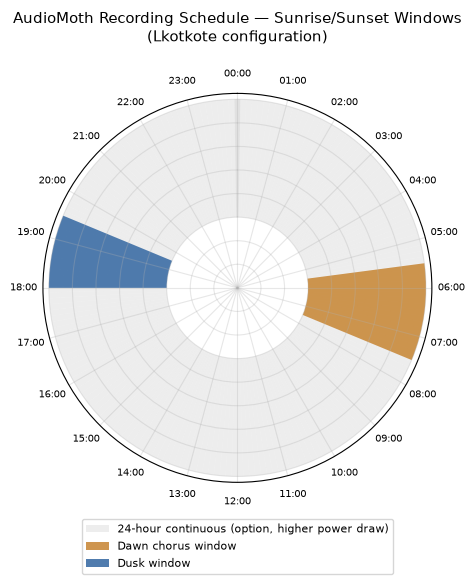

In [10]:
#@title Figure: AudioMoth Recording Schedule { display-mode: "form" }

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

theta_full = np.linspace(0, 2 * np.pi, 200)
ax.bar(theta_full, [1] * len(theta_full), width=2 * np.pi / len(theta_full),
       bottom=0.6, color="#cccccc", alpha=0.35, label="24-hour continuous (option, higher power draw)")

def hours_to_theta(h_start, h_end):
    return (h_start / 24) * 2 * np.pi, ((h_end - h_start) / 24) * 2 * np.pi

for (h0, h1), label, color in [
    ((5.5, 7.5), "Dawn chorus window", "#c98a3c"),
    ((18.0, 19.5), "Dusk window", "#3d6ea5"),
]:
    start, width = hours_to_theta(h0, h1)
    ax.bar(start + width / 2, 1, width=width, bottom=0.6, color=color, alpha=0.9, label=label)

ax.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], fontsize=7)
ax.set_yticklabels([])
ax.set_title("AudioMoth Recording Schedule — Sunrise/Sunset Windows\n(Lkotkote configuration)", fontsize=11, pad=20)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=8, ncol=1)
plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this figure:** this is a 24-hour clock face (midnight at the top, going clockwise). The light grey ring shows what a continuous 24-hour recording schedule would cover; the orange and blue wedges show the narrower dawn-chorus and dusk windows Lkotkote actually uses instead, based on TEK that vocal activity peaks at those times. Recording only in these windows captures the peak vocal activity while using far less battery and SD-card capacity than 24-hour recording.

## Data Download

The cell below loads the four real Xeno-Canto recordings from `xeno_canto_source` (stored on GitHub alongside this notebook — see Data Description), resamples each to **32 kHz mono, 16-bit PCM** to match the AudioMoth settings above, and writes them into the same relative-path folder structure a real deployment would use: `RAW_DIR/<site_name>/<date>/*.WAV`. In a real Lkotkote deployment, this step is instead a field retrieval visit, and the audio already exists as `.WAV` files at that path.


In [11]:
import zipfile
import os

# Download data stored on GitHub
!wget 'https://github.com/climatechange-ai-tutorials/lkotkote-bird-bioacoustics/raw/refs/heads/main/xeno_canto_source.zip'

zip_file_path = 'xeno_canto_source.zip'
extract_dir = './xeno_canto_source'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted '{zip_file_path}' to '{extract_dir}'")

zsh:1: command not found: wget
Extracted 'xeno_canto_source.zip' to './xeno_canto_source'


In [12]:
SAMPLE_RATE = 32_000  # Hz, matches the AudioMoth setting above
DEPLOY_DATE = "2026-06-10"  # illustrative single retrieval date for all four recordings

def load_and_prepare_xc_recording(mp3_path, target_sr=SAMPLE_RATE):
    """Load an MP3 (via librosa/ffmpeg), downmix to mono, resample to the AudioMoth
    sample rate, and peak-normalize -- standardizing a Xeno-Canto download into the
    same format an AudioMoth would actually produce in the field."""
    audio, _ = librosa.load(mp3_path, sr=target_sr, mono=True)
    audio = audio / (np.max(np.abs(audio)) + 1e-9) * 0.9
    return audio.astype(np.float32)

recording_index = []
for _, row in XC_RECORDINGS.iterrows():
    site_dir = os.path.join(RAW_DIR, row["site_name"], DEPLOY_DATE)
    os.makedirs(site_dir, exist_ok=True)
    audio = load_and_prepare_xc_recording(row["mp3_path"])
    wav_path = os.path.join(site_dir, f"{row['site_name']}_{DEPLOY_DATE}_0600.WAV")
    wavfile.write(wav_path, SAMPLE_RATE, (audio * 32767).astype(np.int16))
    recording_index.append({
        "site_name": row["site_name"], "species": row["species"],
        "xc_id": row["xc_id"], "wav_path": wav_path, "duration_s": round(len(audio) / SAMPLE_RATE, 1),
    })
    print(f"Wrote {os.path.relpath(wav_path)}  "
          f"({row['species']}, {row['xc_id']}, {len(audio)/SAMPLE_RATE:.1f}s)")

recording_manifest = pd.DataFrame(recording_index)
print("\nFolder structure created under:", os.path.relpath(RAW_DIR))
recording_manifest

Wrote lkotkote_data/raw_recordings/Lchura/2026-06-10/Lchura_2026-06-10_0600.WAV  (Lesser Masked Weaver (Mairii), XC449647, 15.6s)
Wrote lkotkote_data/raw_recordings/Laawa/2026-06-10/Laawa_2026-06-10_0600.WAV  (White-bellied Go-away-bird (Lkuak), XC747720, 13.1s)
Wrote lkotkote_data/raw_recordings/Lesiteti/2026-06-10/Lesiteti_2026-06-10_0600.WAV  (Pied (Jacobin) Cuckoo (Chupaa), XC601197, 7.4s)
Wrote lkotkote_data/raw_recordings/Soito Naarok/2026-06-10/Soito Naarok_2026-06-10_0600.WAV  (Verreaux's Eagle-Owl (Lugut), XC811860, 41.7s)

Folder structure created under: lkotkote_data/raw_recordings


,site_name,species,xc_id,wav_path,duration_s
0,Lchura,Lesser Masked Weaver (Mairii),XC449647,./lkotkote_data/raw_recordings/Lchura/2026-06-...,15.6
1,Laawa,White-bellied Go-away-bird (Lkuak),XC747720,./lkotkote_data/raw_recordings/Laawa/2026-06-1...,13.1
2,Lesiteti,Pied (Jacobin) Cuckoo (Chupaa),XC601197,./lkotkote_data/raw_recordings/Lesiteti/2026-0...,7.4
3,Soito Naarok,Verreaux's Eagle-Owl (Lugut),XC811860,./lkotkote_data/raw_recordings/Soito Naarok/20...,41.7


### Species call signatures

Rather than assuming a frequency signature per species, we now **measure one directly from each real recording**: the dominant frequency (spectral peak) and an energy-weighted bandwidth around it, computed with Welch's method over the bird-relevant ~200-10,000 Hz band. This is still a simplified, single-number-per-species signature (a real classifier like BirdNET-Analyzer instead uses the full time-frequency pattern via a trained CNN), but it is now grounded in the actual audio rather than an assumption, and it is what the classifier in the Methodology section will use to distinguish between species.


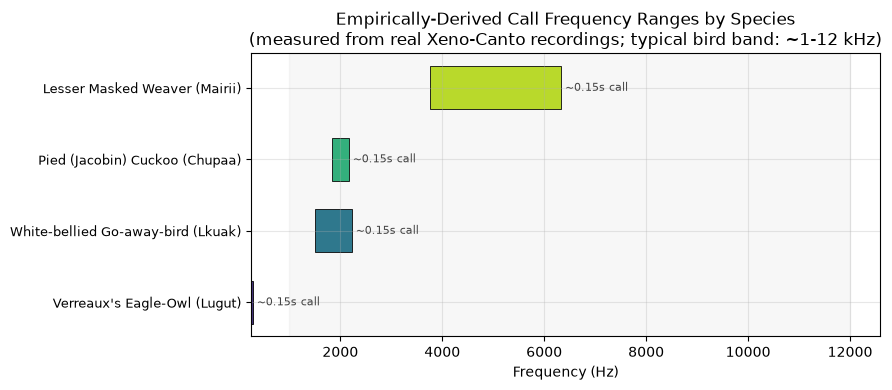

In [13]:
def estimate_call_signature(sr, audio, f_lo=200, f_hi=10000, energy_frac=0.7):
    """Empirically estimate a (center_freq, bandwidth, typical_duration) signature
    directly from a real recording, restricted to the bird-relevant frequency band.
    Bandwidth is the narrowest frequency window (Welch PSD) capturing `energy_frac`
    of the in-band spectral energy, centered as closely as possible on the peak."""
    freqs, psd = signal.welch(audio, fs=sr, nperseg=min(4096, len(audio)))
    band_mask = (freqs >= f_lo) & (freqs <= f_hi)
    freqs_band, psd_band = freqs[band_mask], psd[band_mask]
    peak_freq = freqs_band[np.argmax(psd_band)]

    total_energy = psd_band.sum()
    order = np.argsort(np.abs(freqs_band - peak_freq))
    cum_energy, keep = 0.0, np.zeros_like(psd_band, dtype=bool)
    for idx in order:
        keep[idx] = True
        cum_energy += psd_band[idx]
        if cum_energy >= energy_frac * total_energy:
            break
    band_freqs = freqs_band[keep]
    bandwidth = float(band_freqs.max() - band_freqs.min()) if len(band_freqs) > 1 else 500.0

    # Typical call duration: rough estimate via a quick energy-threshold pass
    # (same technique used properly in Data Preprocessing below).
    f_spec, t_spec, Sxx = signal.spectrogram(audio, fs=sr, nperseg=1024, noverlap=768)
    e = Sxx[(f_spec >= f_lo) & (f_spec <= f_hi), :].sum(axis=0)
    z = (e - e.mean()) / (e.std() + 1e-9)
    active = z > 1.5
    if active.any():
        # median run-length of contiguous "active" frames, converted to seconds
        runs, count = [], 0
        for v in active:
            if v:
                count += 1
            elif count:
                runs.append(count); count = 0
        if count:
            runs.append(count)
        typical_dur = float(np.median(runs)) * (t_spec[1] - t_spec[0]) if runs else 0.5
    else:
        typical_dur = 0.5

    return float(peak_freq), bandwidth, round(max(typical_dur, 0.15), 2)

SPECIES_SIGNATURES = {}
for _, row in XC_RECORDINGS.iterrows():
    site_dir = os.path.join(RAW_DIR, row["site_name"], DEPLOY_DATE)
    wav_file = [f for f in os.listdir(site_dir) if f.upper().endswith(".WAV")][0]
    sr_i, audio_i = wavfile.read(os.path.join(site_dir, wav_file))
    audio_i = audio_i.astype(np.float32) / 32767
    SPECIES_SIGNATURES[row["species"]] = estimate_call_signature(sr_i, audio_i)

fig, ax = plt.subplots(figsize=(9, 4))
species_sorted = sorted(SPECIES_SIGNATURES.items(), key=lambda kv: kv[1][0])
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(species_sorted)))

for i_s, ((species, (f0, bw, dur)), color) in enumerate(zip(species_sorted, colors)):
    low, high = f0 - bw / 2, f0 + bw / 2
    ax.barh(i_s, high - low, left=low, height=0.6, color=color, edgecolor="black", linewidth=0.6)
    ax.text(high + 80, i_s, f"~{dur:.2g}s call", va="center", fontsize=8, color="#444444")

ax.set_yticks(range(len(species_sorted)))
ax.set_yticklabels([s for s, _ in species_sorted], fontsize=9)
ax.set_xlabel("Frequency (Hz)")
ax.set_title("Empirically-Derived Call Frequency Ranges by Species\n(measured from real Xeno-Canto recordings; typical bird band: ~1-12 kHz)")
ax.axvspan(1000, 12000, color="grey", alpha=0.06)
plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this figure:** each horizontal bar spans one species' call frequency range (low to high, in Hz), **measured directly from its real Xeno-Canto recording**, with the approximate typical call duration labelled at the right. The shaded grey band marks the typical ~1-12 kHz bird-vocalization range referenced in the AudioMoth settings. Species with overlapping frequency ranges are exactly the cases where automated detection is hardest to get right, and where the simple frequency-signature classifier used later in Methodology is most likely to confuse one species for another — a real-world limitation shared by (though much more pronounced in this toy classifier than in) actual acoustic classifiers like BirdNET-Analyzer.

## Data Preprocessing

Before running any automated detection, a reviewer would open a recording in Raven Lite to see its **waveform** (amplitude over time) and **spectrogram** (frequency content over time). We recreate that view here, then build a simple **selection table** using an energy-threshold detector — the workshop stand-in for manually drawing selection boxes around candidate calls.


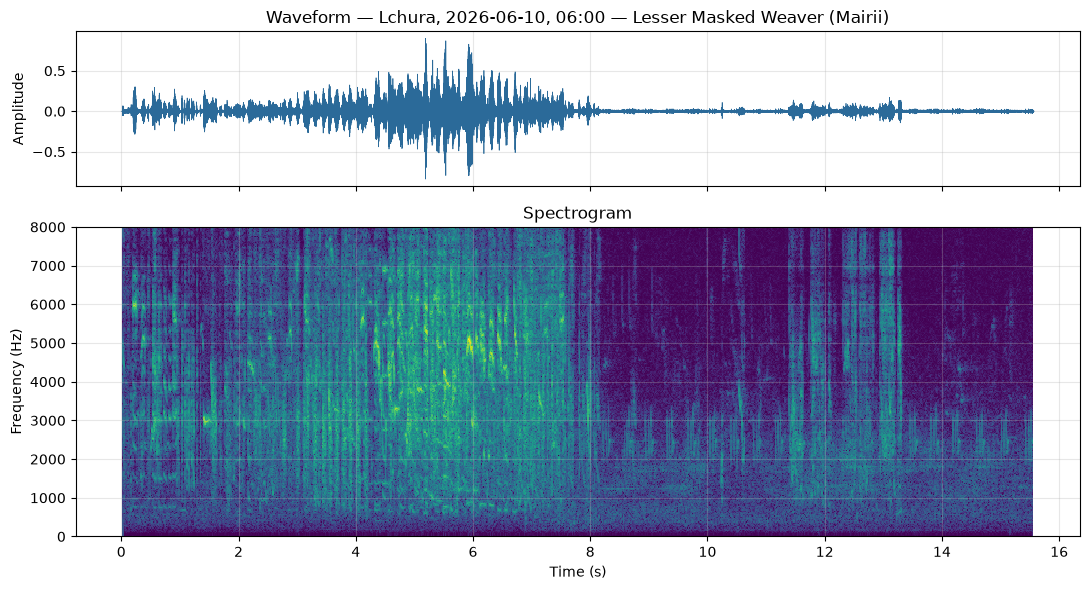

In [14]:
def load_recording(site_name, date=DEPLOY_DATE):
    site_dir = os.path.join(RAW_DIR, site_name, date)
    wav_file = [f for f in os.listdir(site_dir) if f.upper().endswith(".WAV")][0]
    sr, audio = wavfile.read(os.path.join(site_dir, wav_file))
    audio = audio.astype(np.float32) / 32767
    return sr, audio, os.path.join(site_dir, wav_file)

def plot_waveform_and_spectrogram(sr, audio, title=""):
    f, t, Sxx = signal.spectrogram(audio, fs=sr, nperseg=1024, noverlap=512)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                    gridspec_kw={"height_ratios": [1, 2]})
    time_axis = np.linspace(0, len(audio) / sr, len(audio))
    ax1.plot(time_axis, audio, linewidth=0.5, color="#2b6a99")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"Waveform — {title}")

    ax2.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading="auto", cmap="viridis")
    ax2.set_ylabel("Frequency (Hz)")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylim(0, 8000)
    ax2.set_title("Spectrogram")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return f, t, Sxx

sr, audio, wav_path = load_recording("Lchura")  # Lesser Masked Weaver ("Mairii") recording, XC449647
_ = plot_waveform_and_spectrogram(sr, audio, title="Lchura, 2026-06-10, 06:00 — Lesser Masked Weaver (Mairii)")

# Listen to the recording, the same way a Raven Lite reviewer plays back a selection to confirm it by ear.
ipd.Audio(wav_path)

**Reading this figure:** the top panel is the waveform — amplitude over time — useful for spotting *when* something loud happens. The bottom panel is the spectrogram — frequency content over time, colour intensity = signal power in dB — this is where you can actually see the *shape* of a call. The repeated bands are the Lesser Masked Weaver's real calls; background texture is genuine field noise (wind, other birds, insects etc ). This is the same synchronized waveform+spectrogram view a reviewer would see in Raven Lite before manually drawing selection boxes — and you can now listen to the same audio directly above.

In [15]:
def energy_based_selection(sr, audio, low_hz=500, high_hz=6000, z_thresh=2.0):
    '''Equivalent of drawing selection boxes in Raven Lite, done via an energy threshold.'''
    f, t, Sxx = signal.spectrogram(audio, fs=sr, nperseg=1024, noverlap=768)
    band_mask = (f >= low_hz) & (f <= high_hz)
    band_energy = Sxx[band_mask, :].sum(axis=0)
    z = (band_energy - band_energy.mean()) / (band_energy.std() + 1e-9)

    selections, in_call, start_t = [], False, None
    for i, val in enumerate(z):
        if val > z_thresh and not in_call:
            in_call, start_t = True, t[i]
        elif val <= z_thresh and in_call:
            in_call = False
            selections.append({"begin_time_s": round(start_t, 3), "end_time_s": round(t[i], 3),
                                "low_freq_hz": low_hz, "high_freq_hz": high_hz, "label": ""})
    if in_call:
        selections.append({"begin_time_s": round(start_t, 3), "end_time_s": round(t[-1], 3),
                            "low_freq_hz": low_hz, "high_freq_hz": high_hz, "label": ""})
    return pd.DataFrame(selections)

selection_table = energy_based_selection(sr, audio, z_thresh=2.0)
print(f"{len(selection_table)} candidate calls detected (try adjusting z_thresh above).")
selection_table

# Repeat the same auto-detection across ALL FOUR real recordings, building a
# "reference calls" table. IMPORTANT: unlike the earlier synthetic version of
# this notebook, these are NOT verified ground truth -- they are exactly what
# this energy-threshold detector (the Raven-Lite stand-in above) finds, with no
# independent expert check. We use them downstream as a consistency reference,
# not as proof of accuracy (see Results & Discussion and Limitations).
reference_index = []
for _, row in XC_RECORDINGS.iterrows():
    sr_r, audio_r, _ = load_recording(row["site_name"])
    sel = energy_based_selection(sr_r, audio_r, z_thresh=2.0)
    sel["site_name"] = row["site_name"]
    sel["species"] = row["species"]
    sel["start_s"] = sel["begin_time_s"]
    sel["end_s"] = sel["end_time_s"]
    reference_index.append(sel)

reference_calls_all = pd.concat(reference_index, ignore_index=True)
print(f"{len(reference_calls_all)} auto-detected reference calls across all 4 recordings "
      f"(z_thresh=2.0; not independently verified).")
reference_calls_all[["site_name", "species", "start_s", "end_s"]]

8 candidate calls detected (try adjusting z_thresh above).
48 auto-detected reference calls across all 4 recordings (z_thresh=2.0; not independently verified).


,site_name,species,start_s,end_s
0,Lchura,Lesser Masked Weaver (Mairii),4.376,4.400
1,Lchura,Lesser Masked Weaver (Mairii),4.576,4.584
2,Lchura,Lesser Masked Weaver (Mairii),5.176,5.224
3,Lchura,Lesser Masked Weaver (Mairii),5.504,5.552
4,Lchura,Lesser Masked Weaver (Mairii),5.904,6.000
5,Lchura,Lesser Masked Weaver (Mairii),6.304,6.336
6,Lchura,Lesser Masked Weaver (Mairii),6.432,6.464
7,Lchura,Lesser Masked Weaver (Mairii),6.712,6.728
8,Laawa,White-bellied Go-away-bird (Lkuak),6.152,6.296
9,Laawa,White-bellied Go-away-bird (Lkuak),7.040,7.160


**Try it yourself:** raise or lower `z_thresh` above and re-run. A lower threshold catches fainter calls but risks more false positives — the same manual-tuning trade-off a Raven Lite reviewer makes by eye. In the real workflow, a reviewer would now label each selection and export the table alongside the recording (e.g. `Lchura_2026-06-10.wav` + `Lchura_2026-06-10_selections.txt`) so file names stay linked for later stages. The `reference_calls_all` table below applies this same detector across all four real recordings, standing in for that reviewer pass on every site.

<a name="methodology"></a>
# Methodology

This section walks through the four remaining pipeline stages: automated pattern matching, AI species identification, TEK enrichment, and Darwin Core/GBIF export. Each is a subtask below with its own code cells and explanatory text.


## Subtask 1: Automated Pattern Matching (Arbimon-style)

Arbimon scans thousands of hours of audio far faster than manual review, using a **template** built from a verified call. The 5-step Arbimon workflow is: add species → view recordings in the Visualizer → create & name a template → build a site playlist → run a Pattern Matching (PM) job. We recreate the *matching* step with 2D cross-correlation between a template spectrogram and a target recording's spectrogram — the same core idea Arbimon's Pattern Matching uses.


In [16]:
def spectrogram_of(sr, audio, nperseg=512, noverlap=384):
    f, t, Sxx = signal.spectrogram(audio, fs=sr, nperseg=nperseg, noverlap=noverlap)
    return f, t, 10 * np.log10(Sxx + 1e-10)

def build_template(sr, audio, start_s, end_s):
    '''Equivalent of Arbimon's 'Template > Create Template' on a highlighted region.'''
    seg = audio[int(start_s * sr):int(end_s * sr)]
    f, t, Sxx_db = spectrogram_of(sr, seg)
    return f, t, Sxx_db

def pattern_match(sr, audio, template_db, threshold=0.6):
    '''Slide the template across the recording's spectrogram using normalized cross-correlation.'''
    f, t, target_db = spectrogram_of(sr, audio)
    t_len = template_db.shape[1]
    scores = []
    tmpl_flat = (template_db - template_db.mean()) / (template_db.std() + 1e-9)
    for start in range(0, target_db.shape[1] - t_len):
        window = target_db[:, start:start + t_len]
        win_flat = (window - window.mean()) / (window.std() + 1e-9)
        score = np.mean(tmpl_flat * win_flat)
        scores.append(score)
    scores = np.array(scores)
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    matches = []
    i = 0
    while i < len(norm_scores):
        if norm_scores[i] >= threshold:
            j = i
            while j < len(norm_scores) and norm_scores[j] >= threshold:
                j += 1
            best = i + int(np.argmax(norm_scores[i:j]))
            matches.append({"time_s": round(t[best], 3), "match_score": round(float(norm_scores[best]), 3)})
            i = j
        else:
            i += 1
    return pd.DataFrame(matches)

# Build a template from one auto-detected Lesser Masked Weaver ("Mairii") call
# in the Lchura recording (see reference_calls_all in Data Preprocessing).
sr, audio, wav_path = load_recording("Lchura")
mairii_reference = reference_calls_all[
    (reference_calls_all.site_name == "Lchura") &
    (reference_calls_all.species == "Lesser Masked Weaver (Mairii)")
].iloc[0]
tf, tt, template_db = build_template(sr, audio, mairii_reference.start_s, mairii_reference.end_s)

pm_job_name = "Lkotkote Mairii"
matches = pattern_match(sr, audio, template_db, threshold=0.45)
print(f"PM Job '{pm_job_name}' on site 'Lchura': {len(matches)} matches above threshold")
matches

PM Job 'Lkotkote Mairii' on site 'Lchura': 53 matches above threshold


,time_s,match_score
0,0.028,0.630
1,0.112,0.551
2,0.192,0.552
3,0.252,0.457
4,0.356,0.671
5,0.460,0.550
6,0.532,0.721
7,0.804,0.539
8,0.888,0.645
9,1.036,0.596


**Threshold tuning:** just as in Arbimon, the right threshold has to be found empirically per template/site/call type. Try re-running the cell above with `threshold=0.4` or `threshold=0.75` and compare the number of matches to the auto-detected reference count for the Mairii call at this site (`reference_calls_all` filtered to Lchura) — remembering that reference count is itself only an energy-threshold estimate, not verified ground truth.

> **Output format:** once a real Arbimon PM job completes, it exports a CSV of matches per recording/site — exactly the shape of the `matches` DataFrame above.


## Subtask 2: AI Species Identification (BirdNET-Analyzer-style)

In the real Lkotkote pipeline, uploaded audio is run through **[Lkotkote Web Platform](https://lkotkote.com/)** which has in-built **BirdNET-Analyzer**, which identifies species present, assigns a confidence score to each detection, and timestamps it.

Running the actual BirdNET-Analyzer model requires downloading its pretrained weights and is out of scope for a lightweight workshop notebook, so this section uses a **simplified frequency-signature classifier** built from the empirically-measured signal properties in Species call signatures (themselves derived from the real Xeno-Canto recordings). It plays the same role in the pipeline (audio in → species label + confidence + timestamp out).

**On model documentation:** because this classifier is a deterministic, rule-based stand-in (not a trained model with learned parameters), a formal model card is not applicable here. For the real classifier this notebook stands in for, see [BirdNET-Analyzer's documentation and citation](https://github.com/birdnet-team/BirdNET-Analyzer).

**On energy tracking:** per CCAI guidance, we instrument this step with [CodeCarbon](https://codecarbon.io/) to report estimated energy use and emissions, even though this toy classifier's footprint is minimal — the same instrumentation pattern applies directly if you swap in a real BirdNET-Analyzer inference call.


In [17]:
from codecarbon import OfflineEmissionsTracker

def classify_segment(sr, audio_segment, signatures=SPECIES_SIGNATURES):
    '''Toy classifier: compares a segment's dominant frequency band against known species signatures.
    This stands in for BirdNET-Analyzer's CNN-based classification for workshop purposes only.'''
    freqs, psd = signal.welch(audio_segment, fs=sr, nperseg=min(1024, len(audio_segment)))
    dominant_freq = freqs[np.argmax(psd)]

    best_species, best_score = None, -np.inf
    for species, (f0, bw, _dur) in signatures.items():
        distance = abs(dominant_freq - f0) / (bw / 2 + 1e-9)
        score = np.exp(-distance)
        if score > best_score:
            best_species, best_score = species, score
    confidence = float(np.clip(best_score, 0, 1))
    return best_species, round(confidence, 3)

def run_ai_detection(site_name, matches_df, sr, audio, window_s=0.6, confidence_floor=0.05):
    '''Apply the classifier at each Arbimon-style match time, producing a BirdNET-style detection table.'''
    detections = []
    for _, row in matches_df.iterrows():
        center = row["time_s"]
        start_idx = max(0, int((center - window_s / 2) * sr))
        end_idx = min(len(audio), int((center + window_s / 2) * sr))
        segment = audio[start_idx:end_idx]
        if len(segment) < 32:
            continue
        species, confidence = classify_segment(sr, segment)
        if confidence >= confidence_floor:
            detections.append({
                "site_name": site_name, "timestamp_s": center,
                "species": species, "confidence": confidence,
                "recording_datetime": f"{DEPLOY_DATE}T06:00:00",
            })
    return pd.DataFrame(detections)

tracker = OfflineEmissionsTracker(country_iso_code="KEN", log_level="error", save_to_file=False)
tracker.start()
ai_detections = run_ai_detection("Lchura", matches, sr, audio)
emissions_kg = tracker.stop()

print(f"Estimated emissions for this inference step: {emissions_kg:.3e} kg CO2eq")
ai_detections.sort_values("confidence", ascending=False)

/Users/pierrekaramountzos/Desktop/Folders/London/PhD/Conferences and Workshops/CCAI-Virtual-Summer-School/CCAI/lib/python3.11/site-packages/codecarbon/core/gpu.py:4: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
[codecarbon INFO @ 15:31:23] offline tracker init


Estimated emissions for this inference step: 3.639e-08 kg CO2eq


,site_name,timestamp_s,species,confidence,recording_datetime
43,Lchura,12.072,Lesser Masked Weaver (Mairii),0.982,2026-06-10T06:00:00
35,Lchura,6.180,Lesser Masked Weaver (Mairii),0.958,2026-06-10T06:00:00
26,Lchura,2.764,Lesser Masked Weaver (Mairii),0.936,2026-06-10T06:00:00
25,Lchura,2.736,Lesser Masked Weaver (Mairii),0.936,2026-06-10T06:00:00
24,Lchura,2.552,Lesser Masked Weaver (Mairii),0.936,2026-06-10T06:00:00
32,Lchura,4.220,Lesser Masked Weaver (Mairii),0.902,2026-06-10T06:00:00
33,Lchura,4.236,Lesser Masked Weaver (Mairii),0.902,2026-06-10T06:00:00
34,Lchura,4.384,Lesser Masked Weaver (Mairii),0.902,2026-06-10T06:00:00
45,Lchura,12.472,White-bellied Go-away-bird (Lkuak),0.879,2026-06-10T06:00:00
46,Lchura,12.616,White-bellied Go-away-bird (Lkuak),0.879,2026-06-10T06:00:00


> **In production:** this cell would instead call `BirdNET-Analyzer` (or the Lkotkote platform's **Audio Upload → Run AI Bird Detection** step, which wraps BirdNET-Analyzer). The interface — audio in, `(species, confidence, timestamp)` out — is identical, so everything from Subtask 3 onward works the same way regardless of which classifier produced it.
>
> **Reference implementation (not run in this notebook):**
> ```python
> # pip install birdnetlib tensorflow  # (or tflite-runtime on constrained hardware)
> # from birdnetlib import Recording
> # from birdnetlib.analyzer import Analyzer
> #
> # analyzer = Analyzer()  # <- on first use, this downloads the pretrained BirdNET-Analyzer
> #                         #    global model (~50 MB) from the BirdNET-Analyzer GitHub releases
> #                         #    (https://github.com/birdnet-team/BirdNET-Analyzer/releases) into a
> #                         #    local cache folder. No manual download or account is needed.
> # recording = Recording(analyzer, wav_path, lat=1.148, lon=36.970, date=deploy_date, min_conf=0.25)
> # recording.analyze()
> # recording.detections
> ```
> Swapping this real call in for `run_ai_detection()` above is a drop-in replacement — Subtask 3 (TEK enrichment) and Subtask 4 (Darwin Core export) are unchanged either way, since both only depend on the `(species, confidence, timestamp)` output shape.
>
> As with the real workflow, cross-check AI detections against the Raven Lite-style selection table (Data Preprocessing) as a sanity check before trusting them downstream.


## Subtask 3: TEK Enrichment — the Lkotkote Layer

This is Lkotkote's core innovation: **enriching AI detections with Indigenous ecological knowledge.** For each detected species, community members (or the recording contributor) add local names, seasonal indicators, behavioural insights, and cultural meaning. This converts a plain detection into context-rich ecological intelligence.


In [18]:
# TEK metadata table -- this is what a community annotator fills in on the Lkotkote platform.
# Sourced directly from Samburu TEK documentation provided for this tutorial (see References).
tek_annotations = pd.DataFrame([
    {
        "species": "Lesser Masked Weaver (Mairii)",
        "local_name": "Mairii",
        "seasonal_indicator": "Predicts rain — the rains are within days",
        "cultural_meaning": "A trusted short-range rain forecast in Samburu oral knowledge; "
                             "increased calling/activity is read as an imminent-rain signal",
    },
    {
        "species": "White-bellied Go-away-bird (Lkuak)",
        "local_name": "Lkuak",
        "seasonal_indicator": "Predicts danger — predators or strangers approaching",
        "cultural_meaning": "A sentinel species; its alarm-like call is read as a warning of approaching "
                             "danger, whether predator or unfamiliar person",
    },
    {
        "species": "Pied (Jacobin) Cuckoo (Chupaa)",
        "local_name": "Chupaa",
        "seasonal_indicator": "Predicts rain — the rains are within days",
        "cultural_meaning": "Like the Lesser Masked Weaver, its call is a recognized short-range rain "
                             "forecast; Jacobin/Pied Cuckoos are also known intra-African rain-linked migrants",
    },
    {
        "species": "Verreaux's Eagle-Owl (Lugut)",
        "local_name": "Lugut",
        "seasonal_indicator": "Bad omen — often associated with death",
        "cultural_meaning": "Not a seasonal/weather indicator like the other three; its call carries strong "
                             "cultural significance as a bad omen, illustrating that TEK bird associations "
                             "are not always about climate — some are purely cultural, and that distinction "
                             "matters for how (and whether) such an annotation should be published (see Limitations)",
    },
])
tek_annotations

,species,local_name,seasonal_indicator,cultural_meaning
0,Lesser Masked Weaver (Mairii),Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
1,White-bellied Go-away-bird (Lkuak),Lkuak,Predicts danger — predators or strangers appro...,A sentinel species; its alarm-like call is rea...
2,Pied (Jacobin) Cuckoo (Chupaa),Chupaa,Predicts rain — the rains are within days,"Like the Lesser Masked Weaver, its call is a r..."
3,Verreaux's Eagle-Owl (Lugut),Lugut,Bad omen — often associated with death,Not a seasonal/weather indicator like the othe...


In [19]:
def add_annotation(species, local_name, seasonal_indicator, cultural_meaning):
    """Add a TEK annotation to the tek_annotations table."""
    global tek_annotations
    new_entry = {
        "species": species,
        "local_name": local_name,
        "seasonal_indicator": seasonal_indicator,
        "cultural_meaning": cultural_meaning,
    }
    tek_annotations = pd.concat([tek_annotations, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Added annotation for species: {species}")
add_annotation('rayquaza', 'eel bird', 'Groudon and Kyogre are fighting', 'A trusted forecast of incoming return to peace')

Added annotation for species: rayquaza


In [20]:
# Merge AI detections with the TEK annotation layer -- this is the "Lkotkote layer" in code form.
enriched = ai_detections.merge(tek_annotations, on="species", how="left")
enriched

,site_name,timestamp_s,species,confidence,recording_datetime,local_name,seasonal_indicator,cultural_meaning
0,Lchura,0.028,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
1,Lchura,0.112,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
2,Lchura,0.192,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
3,Lchura,0.252,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
4,Lchura,0.356,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
5,Lchura,0.460,Lesser Masked Weaver (Mairii),0.486,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
6,Lchura,0.532,Lesser Masked Weaver (Mairii),0.475,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
7,Lchura,0.804,Lesser Masked Weaver (Mairii),0.216,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
8,Lchura,0.888,Lesser Masked Weaver (Mairii),0.216,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...
9,Lchura,1.036,Lesser Masked Weaver (Mairii),0.216,2026-06-10T06:00:00,Mairii,Predicts rain — the rains are within days,A trusted short-range rain forecast in Samburu...


**Try it yourself:** write a small function `add_annotation(species, local_name, seasonal_indicator, cultural_meaning)` that appends a new row to `tek_annotations`, then re-run the merge cell above. This mirrors the Lkotkote web app's **Add the TEK Annotation Layer** step.


## Subtask 4: Darwin Core / GBIF Export

Once validated, the TEK-enriched dataset is converted into **Darwin Core–compliant** tables, ready for publishing through [GBIF](https://www.gbif.org/): **Occurrence** (one record per confirmed species detection), **Event** (one record per sampling event), and **MeasurementOrFact** (supplementary structured data, including TEK-derived attributes).


In [21]:
def to_darwin_core(enriched_df, sites_df):
    site_lookup = sites_df.set_index("site_name")[["lat", "lon"]].to_dict("index")

    occurrence_rows, event_rows, measurement_rows = [], [], []
    for _, row in enriched_df.iterrows():
        occ_id = str(uuid.uuid4())
        event_id = f"{row['site_name']}_{DEPLOY_DATE}_0600"
        coords = site_lookup.get(row["site_name"], {"lat": None, "lon": None})

        occurrence_rows.append({
            "occurrenceID": occ_id, "eventID": event_id,
            "scientificName": row["species"], "eventDate": row["recording_datetime"],
            "decimalLatitude": coords["lat"], "decimalLongitude": coords["lon"],
            "basisOfRecord": "MachineObservation", "identificationConfidence": row["confidence"],
        })
        event_rows.append({
            "eventID": event_id, "samplingProtocol": "AudioMoth passive acoustic monitoring",
            "eventDate": row["recording_datetime"], "locality": row["site_name"],
            "decimalLatitude": coords["lat"], "decimalLongitude": coords["lon"],
        })
        measurement_rows.append({
            "occurrenceID": occ_id, "measurementType": "seasonalIndicator",
            "measurementValue": row.get("seasonal_indicator", ""),
            "measurementRemarks": row.get("cultural_meaning", ""),
        })

    occurrence = pd.DataFrame(occurrence_rows).drop_duplicates()
    event = pd.DataFrame(event_rows).drop_duplicates(subset=["eventID"])
    measurement = pd.DataFrame(measurement_rows).drop_duplicates()
    return occurrence, event, measurement

occurrence_df, event_df, measurement_df = to_darwin_core(enriched, sites)

occurrence_df.to_csv(os.path.join(EXPORT_DIR, "occurrence.csv"), index=False)
event_df.to_csv(os.path.join(EXPORT_DIR, "event.csv"), index=False)
measurement_df.to_csv(os.path.join(EXPORT_DIR, "measurementorfact.csv"), index=False)

print("Darwin Core files written to:", os.path.relpath(EXPORT_DIR))
occurrence_df.head()

Darwin Core files written to: lkotkote_data/darwin_core_export


,occurrenceID,eventID,scientificName,eventDate,decimalLatitude,decimalLongitude,basisOfRecord,identificationConfidence
0,893ecc32-a599-456b-ac43-4b1121ca0260,Lchura_2026-06-10_0600,Lesser Masked Weaver (Mairii),2026-06-10T06:00:00,1.1483,36.9701,MachineObservation,0.486
1,05f2d428-cae6-4469-a0e5-df75e3b667d1,Lchura_2026-06-10_0600,Lesser Masked Weaver (Mairii),2026-06-10T06:00:00,1.1483,36.9701,MachineObservation,0.486
2,cff0135a-075e-409f-93c3-41d2be0728d9,Lchura_2026-06-10_0600,Lesser Masked Weaver (Mairii),2026-06-10T06:00:00,1.1483,36.9701,MachineObservation,0.486
3,02eb3ecc-80eb-4b65-a2ca-df0df7c887a4,Lchura_2026-06-10_0600,Lesser Masked Weaver (Mairii),2026-06-10T06:00:00,1.1483,36.9701,MachineObservation,0.486
4,0e3edd0e-41ac-4fd6-b1d7-3bb1547323f8,Lchura_2026-06-10_0600,Lesser Masked Weaver (Mairii),2026-06-10T06:00:00,1.1483,36.9701,MachineObservation,0.486


> **Data governance note:** not every field belongs in an openly published GBIF record by default. In practice, the community decides — per the CARE Principles (see Results & Discussion) — which TEK fields are published openly and which are retained for internal/community use only.


<a name="results-and-discussion"></a>
# Results & Discussion

### Checking detections against auto-detected reference calls

Because this notebook now uses **real** field recordings rather than self-generated synthetic audio, we no longer have privileged knowledge of the "true" calls in a recording. What we *do* have is `reference_calls_all` — the energy-threshold detections from Data Preprocessing, standing in for a first-pass Raven Lite review. Comparing AI detections against that table is therefore a **self-consistency check between two automated methods**, not a validated-accuracy check against expert-verified ground truth. A real deployment would use human-verified Raven Lite selection tables for this comparison instead (see Limitations).


In [22]:
def evaluate_against_ground_truth(detections_df, ground_truth_df, site_name, tolerance_s=1.0):
    site_truth = ground_truth_df[ground_truth_df.site_name == site_name].copy()
    site_truth["matched"] = False
    true_positives = 0
    for _, det in detections_df.iterrows():
        candidates = site_truth[~site_truth["matched"]]
        within = candidates[
            (candidates["start_s"] - tolerance_s <= det["timestamp_s"]) &
            (det["timestamp_s"] <= candidates["end_s"] + tolerance_s)
        ]
        if len(within) > 0:
            site_truth.loc[within.index[0], "matched"] = True
            true_positives += 1
    n_detections = len(detections_df)
    n_truth = len(site_truth)
    precision = true_positives / n_detections if n_detections else 0.0
    recall = true_positives / n_truth if n_truth else 0.0
    return pd.DataFrame([{
        "site_name": site_name, "true_calls": n_truth, "detections": n_detections,
        "true_positives": true_positives, "precision": round(precision, 2), "recall": round(recall, 2),
    }])

eval_results = evaluate_against_ground_truth(ai_detections, reference_calls_all, "Lchura")
eval_results

,site_name,true_calls,detections,true_positives,precision,recall
0,Lchura,8,53,4,0.08,0.5


On this small real-audio example, precision/recall will vary run to run depending on the pattern-matching threshold chosen in Subtask 1 and the classifier's confidence floor in Subtask 2 — this mirrors the real-world need to tune both empirically per site and call type, as the tutorial notes throughout. Remember that here "true_calls" means *auto-detected reference calls*, not expert-verified ground truth (see note above) — so these numbers measure agreement between two automated stages of this notebook's own pipeline, not real-world accuracy.

### Detections by site and species


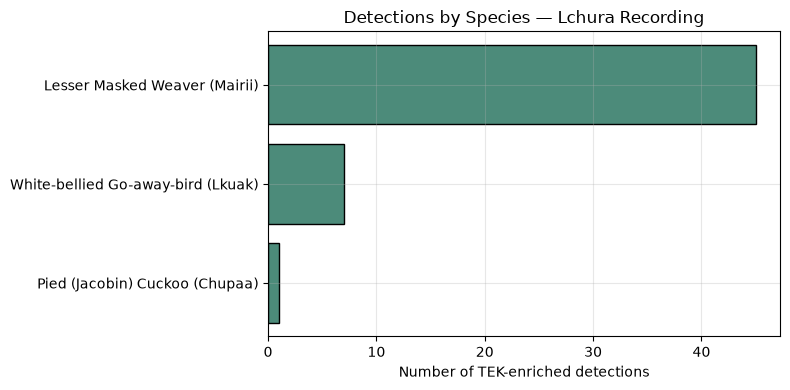

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
if len(enriched) > 0:
    counts = enriched.groupby("species").size().sort_values()
    ax.barh(counts.index, counts.values, color="#4c8b7a", edgecolor="black")
    ax.set_xlabel("Number of TEK-enriched detections")
    ax.set_title("Detections by Species — Lchura Recording")
else:
    ax.text(0.5, 0.5, "No detections above threshold\n(try lowering the pattern-matching threshold)",
            ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this figure:** each bar is one species, with length equal to the number of TEK-enriched detections logged for it in the Lchura recording. This is the final, human-readable summary of everything the pipeline did upstream: pattern matching flagged candidate call times, the classifier assigned each a species label and confidence score, and the TEK layer attached local names and seasonal meaning — so a bar here represents a fully enriched, publishable detection, not just a raw acoustic match.

## Limitations

- **Model & data limitations:** BirdNET-Analyzer and pattern-matching templates can produce false positives (misidentified calls, background noise) and false negatives (missed calls in dense or overlapping soundscapes), especially near a chosen confidence/threshold cutoff. Model training data may under-represent certain regional species or dialectal call variants, biasing detection accuracy for some species over others. Environmental noise (wind, livestock, human activity) degrades recording quality and detection reliability, particularly at low gain or in exposed sites. The toy classifier used in Subtask 2 is far simpler than a real deep-learning model and should not be used for any real ecological inference — this matters more now that the audio is real: unlike the earlier synthetic-chirp version, real bird calls have rich harmonic structure that a single-peak-frequency signature cannot capture, so expect visibly more confusion between species than a synthetic demo would show.
- **Bias and societal impact:** because AI bird-sound datasets are often built from recordings and labels concentrated in well-studied regions, models can under-perform on regionally distinctive species or dialects — the same risk applies here: all four species in this notebook were recorded by independent Xeno-Canto contributors, not by the Lkotkote program itself, so their recording conditions (location, equipment, background noise) are not representative of an actual Samburu AudioMoth deployment. Addressing this requires deliberately incorporating regionally representative training data and community validation, not just aggregate accuracy metrics.
- **Data gaps:** for a discussion of the broader categories of data gaps that can affect climate-relevant datasets like this one (e.g., spatial, temporal, or representational gaps), see CCAI's [data gaps taxonomy](https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps).
- **Data sovereignty and responsible TEK use:** Traditional Ecological Knowledge is **community-held knowledge, not open data by default.** Lkotkote is built around the **[CARE Principles for Indigenous Data Governance](https://www.gida-global.org/care)**, which sit alongside — and sometimes in tension with — the FAIR principles common in open science:

| Principle | Meaning |
|---|---|
| **C**ollective Benefit | Data use should benefit the community that generated the knowledge, not only external researchers |
| **A**uthority to Control | The community retains the right to decide what TEK is shared, in what form, and with whom |
| **R**esponsibility | Those working with TEK have an ongoing duty of care in how it is represented and used |
| **E**thics | Indigenous rights and interests are the primary consideration in data-related decisions |

  A concrete example from this notebook: the Verreaux's Eagle-Owl ("Lugut") TEK annotation records a cultural association with death, not a seasonal/climate signal like the other three species. Publishing that kind of culturally sensitive association openly (versus keeping it community-controlled) is exactly the sort of per-field decision Authority to Control is meant to protect — it should not be published by default just because the underlying species detection is.

  Practically, this means: securing informed consent before recording or publishing TEK contributions, correctly attributing knowledge to the community (not anonymizing it into generic "local knowledge"), and giving the community control over which fields are published openly via GBIF versus retained for internal/community use only.

- **Unverified reference calls:** the `reference_calls_all` table (Data Preprocessing) used to sanity-check detections in Results & Discussion is itself produced by an automated energy-threshold detector, not an expert reviewer. Treat evaluation numbers in this notebook as a self-consistency check between automated stages, not a validated accuracy measurement — a real deployment would substitute genuine Raven-Lite-reviewed, human-verified selection tables for this role.
- **Third-party audio licensing:** the four Xeno-Canto recordings bundled with this notebook (`xeno_canto_source/`) are real, copyrighted field recordings contributed by independent recordists under their own chosen Creative Commons licenses (see References for each recording's citation). They are included here for workshop/educational use; check the individual license terms on [xeno-canto.org](https://xeno-canto.org/) before any other reuse or redistribution.


<a name="pathway-to-deployment"></a>
# Pathway to Deployment & Pathway to Impact

### From notebook to pilot deployment

The block diagram in Background & Prerequisites maps every notebook step to its real-world counterpart. Concretely, moving from this notebook to a field pilot means:

1. **Community engagement first, not last.** Before any sensor goes out, confirm TEK-informed site selection with the community and secure informed consent for how recordings and TEK annotations will be used and published (CARE: Authority to Control).
2. **Hardware acquisition & configuration.** Procure AudioMoths, SD cards, and batteries; configure each device once per the Recording Configuration table in Data Description (32 kHz, Medium gain, sunrise/sunset schedule).
3. **Pilot deployment (1-2 sites, 1-2 weeks).** Validate that the sunrise/sunset schedule actually captures the target dawn chorus before scaling to all seven sites.
4. **Swap remaining simulated components for real tools, one at a time.** This notebook already uses real audio (Data Download); the next swaps are replacing these Xeno-Canto reference recordings with actual GPS-tagged AudioMoth `.WAV` files collected at the literal Lkotkote sites, replacing `classify_segment()` with a real `birdnetlib`/BirdNET-Analyzer call (Subtask 2), and — once recording volume justifies it — replacing the in-notebook `pattern_match()` with an actual Arbimon PM job (Subtask 1).
5. **Stand up the TEK annotation workflow.** Identify community annotators, agree on which fields to capture (local name, seasonal indicator, cultural meaning), and agree — **with the community, not for them** — on the open-vs-restricted publication split used in the Darwin Core export (Subtask 4 / Data governance note).
6. **Publish incrementally.** Start with a small, community-approved Occurrence + Event export to GBIF; expand scope as trust and process maturity increase.

### Pathway to impact

- **For conservation science:** structured, verifiable, TEK-enriched detection data becomes part of the global biodiversity record (via GBIF), improving species-distribution and phenology models used in climate-impact assessments.
- **For the Samburu community:** a durable, community-controlled record of ecological knowledge that supports adaptive decisions — e.g. anticipating rainfall for livestock movement or water-access planning — while keeping authority over sensitive cultural knowledge with the community itself (see CARE Principles above).
- **Beyond birds:** the same **sensor → AI detection → community enrichment → governed publishing** pattern generalizes to other bioacoustic monitoring (e.g. large mammals, insects, frogs) and other Indigenous/local-knowledge domains beyond Samburu or Kenya.

### Concrete next steps for this codebase

- Swap the toy classifier in Subtask 2 for the real [BirdNET-Analyzer](https://github.com/birdnet-team/BirdNET-Analyzer) on your own recordings.
- Replace the Xeno-Canto reference recordings in Data Download with real, GPS-tagged AudioMoth `.WAV` files collected at the literal Lkotkote sites — the folder structure and every downstream cell will work unchanged.
- Explore the real [Arbimon](https://arbimon.org/) platform for large-scale pattern matching, and [Raven Lite 2.0](https://store.birds.cornell.edu/collections/downloadable-software/products/raven-lite-2-0-free-license) for manual review with playback.
- Apply this same **sensor → AI detection → community enrichment → open publishing** architecture to other climate-sensitive indicator species (e.g. insects, frogs, mammals) or other Indigenous/local-knowledge contexts.
- Other climate-related bioacoustic datasets to explore: the [Xeno-canto](https://xeno-canto.org/) bird sound archive, and BirdNET-Analyzer's own [training datasets and documentation](https://github.com/birdnet-team/BirdNET-Analyzer).
- Read the [CARE Principles for Indigenous Data Governance](https://www.gida-global.org/care) in full before publishing any community-derived dataset.


<a name="references"></a>
# References

*   Lkotkote: [https://lkotkote.com](https://lkotkote.com)
*   Open Acoustic Devices (AudioMoth): [https://www.openacousticdevices.info](https://www.openacousticdevices.info)
*   Raven Lite 2.0: [https://store.birds.cornell.edu/collections/downloadable-software/products/raven-lite-2-0-free-license](https://store.birds.cornell.edu/collections/downloadable-software/products/raven-lite-2-0-free-license)
*   Arbimon: [https://arbimon.org/](https://arbimon.org/)
*   Kahl, S., Wood, C. M., Eibl, M., & Klinck, H. (2021). BirdNET: A deep learning solution for avian diversity monitoring. *Ecological Informatics*, 61, 101236. [https://github.com/birdnet-team/BirdNET-Analyzer](https://github.com/birdnet-team/BirdNET-Analyzer)
*   GBIF: [https://www.gbif.org](https://www.gbif.org)
*   Darwin Core standard: [https://dwc.tdwg.org](https://dwc.tdwg.org)
*   CARE Principles for Indigenous Data Governance: [https://www.gida-global.org/care](https://www.gida-global.org/careprinciples)
*   CCAI Taxonomy of Data Gaps: [https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps](https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps)
*   CodeCarbon: [https://codecarbon.io/](https://codecarbon.io/)
*   Rule A, Birmingham A, Zuniga C, et al. (2019). Ten simple rules for writing and sharing computational analyses in Jupyter Notebooks. *PLoS Comput Biol* 15(7): e1007007. [https://doi.org/10.1371/journal.pcbi.1007007](https://doi.org/10.1371/journal.pcbi.1007007)
*   Samburu Traditional Ecological Knowledge associated with the four bird calls used in this notebook — compiled for this tutorial ("TEK Associated With the Sounds", provided by the tutorial author)
*   Audio recordings, via [Xeno-Canto](https://xeno-canto.org/) (cite each per Xeno-Canto's [citation guidelines](https://xeno-canto.org/about/terms):
    *   Lesser Masked Weaver (*Ploceus intermedius*), recording [XC449647](https://xeno-canto.org/449647)
    *   White-bellied Go-away-bird (*Crinifer leucogaster*), recording [XC747720](https://xeno-canto.org/747720)
    *   Pied/Jacobin Cuckoo (*Clamator jacobinus*), recording [XC601197](https://xeno-canto.org/601197)
    *   Verreaux's Eagle-Owl (*Bubo lacteus*), recording [XC811860](https://xeno-canto.org/811860)


---
### Dependency & environment report

Here, we print exact dependency versions below using `watermark`, in addition to the companion `requirements.txt` submitted alongside this notebook.


In [24]:
%load_ext watermark
%watermark -v -iv -p numpy,pandas,scipy,matplotlib,librosa,soundfile,codecarbon -u -d

Last updated: 2026-08-24

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 9.15.0

numpy     : 1.26.4
pandas    : 3.0.5
scipy     : 1.17.1
matplotlib: 3.11.1
librosa   : 0.11.0
soundfile : 0.14.0
codecarbon: 2.8.4

IPython   : 9.15.0
codecarbon: 2.8.4
librosa   : 0.11.0
matplotlib: 3.11.1
numpy     : 1.26.4
pandas    : 3.0.5
scipy     : 1.17.1
soundfile : 0.14.0

